In [10]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from tardis.io.atom_data.util import download_atom_data
import pandas as pd
import matplotlib.colors as colors
from astropy import units as u
from stardis.base import run_stardis
from astropy.stats import sigma_clip
import ipywidgets as widgets
from ipywidgets import interact
from src.funcs import convert_wavelength_air2vacuum, continuum_visualizer, bass_compare
download_atom_data('kurucz_cd23_chianti_H_He')

Atomic Data kurucz_cd23_chianti_H_He already exists in /home/keshav/Downloads/tardis-data/kurucz_cd23_chianti_H_He.h5. Will not download - override with force_download=True.


In [2]:
## Defines the range for the simulated wavelegths
tracing_lambdas = np.mgrid[6061:7061:0.1]* u.Angstrom

sim = run_stardis('stardis_example.yml', tracing_lambdas)

To get the continuum from stardis, set 'disable = True' in the line section in yml file.

In [3]:
sim2 = run_stardis('Nolines.yml', tracing_lambdas)

In [4]:
help(src.funcs)

Help on module src.funcs in src:

NAME
    src.funcs

FUNCTIONS
    bass_compare(obs_x, obs_y, sim_x, sim_y, x_min=6061, x_max=7061)
        Compare the observed solar spectrum with the STARDIS simulation
        Parameters
        -----------
        wavelength: array-like
            Wavelengths of the stardis solar spectrum in Angstroms
        flux: array-like
            Flux densities of the stardis solar spectrum in erg/s/cm^2/Angstrom

        Returns
        --------
        None

    continuum_visualizer(x1, y1, x2, y2, x_min=6061, x_max=7061)
        Visualize the continuum of the STARDIS simulation
        Parameters
        -----------
        wavelength: array-like
            Wavelengths of the stardis solar spectrum in Angstroms
        flux: array-like
            Flux densities of the stardis solar spectrum in erg/s/cm^2/Angstrom

        Returns
        --------
        None

    convert_wavelength_air2vacuum(wavelength_air)
        Convert air wavelength to vacuum w

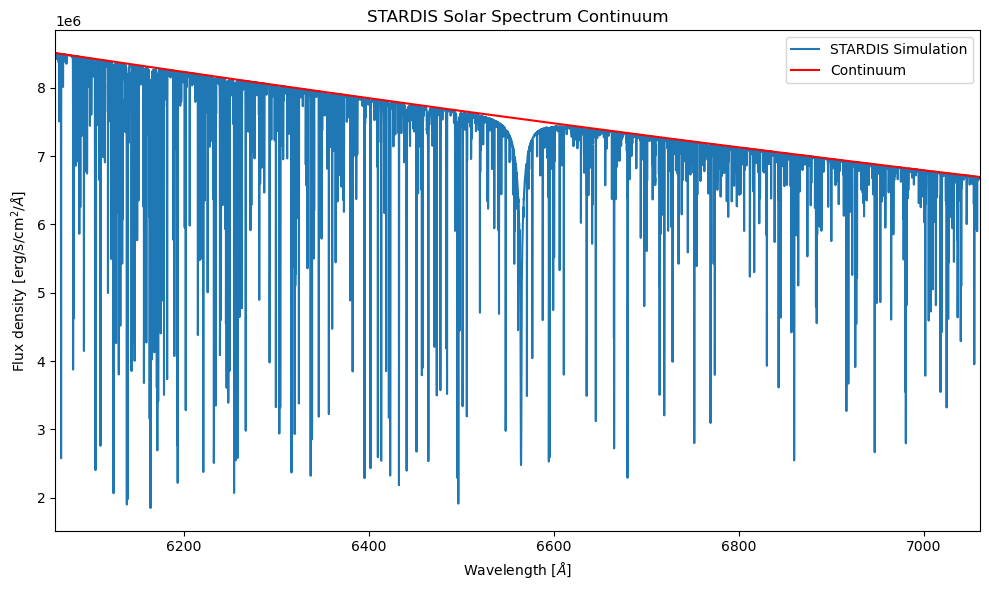

In [14]:
data = pd.read_csv('../data/getSolarSpectrumDB.dat', skipinitialspace=True)
wave = data.iloc[:, 0]
flux = data.iloc[:, 1]
wave_vac = convert_wavelength_air2vacuum(wave)


continuum_visualizer(sim2.lambdas, sim2.spectrum_lambda, sim.lambdas, sim.spectrum_lambda)

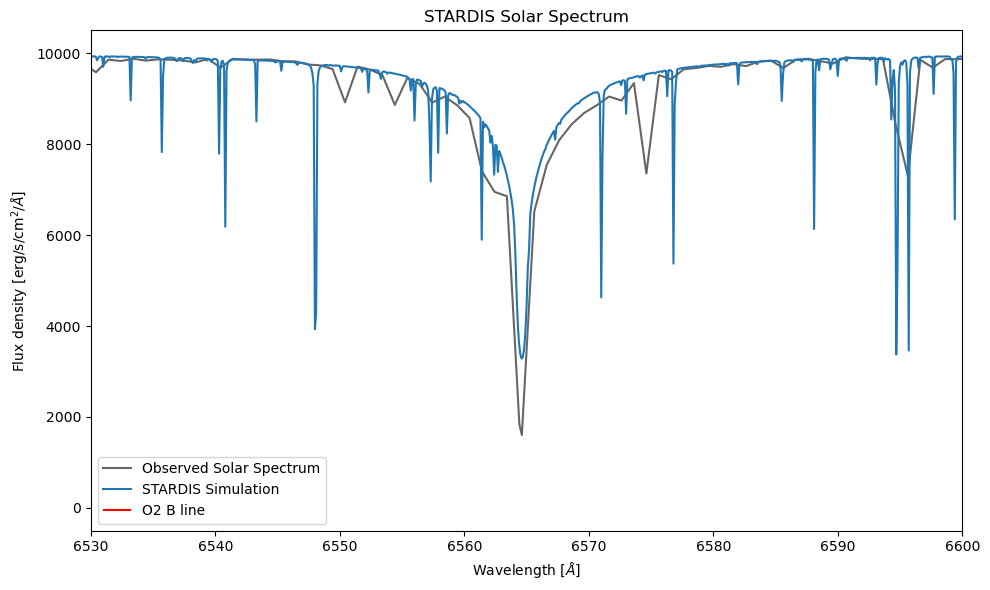

In [15]:
'''
plt.figure(figsize=(10,6))
plt.plot(sim2.lambdas, sim2.spectrum_lambda, color='red')
plt.plot(sim.lambdas, sim.spectrum_lambda)
plt.xlim((6062,7061))
plt.title("STARDIS Solar Spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
plt.tight_layout()
'''

y_best = sim.spectrum_lambda/sim2.spectrum_lambda*10000

plt.figure(figsize=(10,6))
plt.plot(wave_vac, flux, label='Observed Solar Spectrum', color = 'black', alpha = 0.6)

plt.xlim((6530,6600)) # Zoom in on the H-alpha line
#plt.xlim((6800,6925)) # Zoom in on the O2 B line
plt.title("STARDIS Solar Spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
plt.tight_layout()

plt.plot (sim.lambdas, y_best, label='STARDIS Simulation')
#plt.vlines(6564.6, ymin=0, ymax=10000, color='red', label='H-alpha line')
plt.vlines(6869.4, ymin=0, ymax=10000, color='red', label='O2 B line')
plt.legend()
plt.show()

np.mgrid[6540:6590:.01]* u.Angstrom --> This makes a list of wavelengths from x to y in steps of z in unit Angstorm
.yml file defines the physics of the star. Then run_tardis calculates it for each wavelength 

## Manual Curve fit

-1579.4139539938699
17732328.48931088


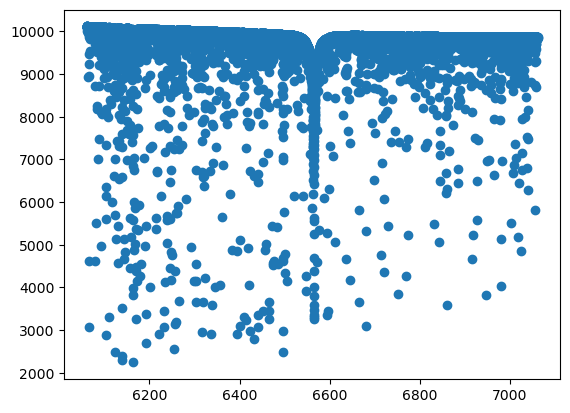

In [16]:
# Genrate a curve fit for the spectrum
x = sim.lambdas.value
y = sim.spectrum_lambda.value

slope, intercept = np.polyfit(x, y, 1)
result = np.array(x) * slope + intercept
#Result is the fitted line, we can use it to get the new y values for the plot

y_new = sim.spectrum_lambda / result *9700

plt.plot(x, y_new, 'o', label='Data')
print(slope)
print(intercept)


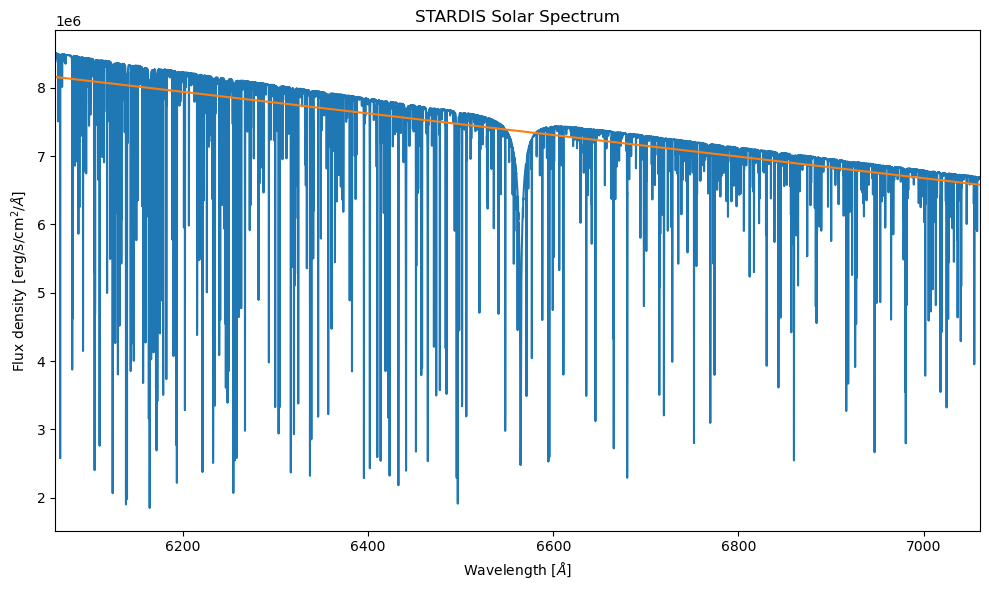

In [17]:
plt.figure(figsize=(10,6))
plt.plot(sim.lambdas, sim.spectrum_lambda)

plt.xlim((6062,7061))
plt.title("STARDIS Solar Spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
plt.tight_layout()

plt.plot (sim.lambdas, result)

plt.show()

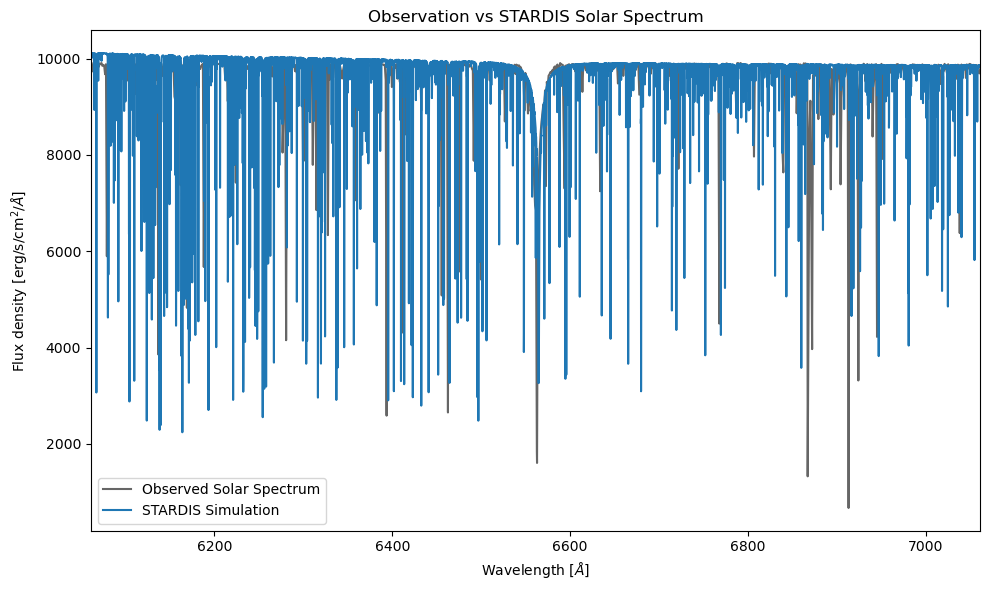

In [20]:
bass_compare(wave, flux, sim.lambdas, y_new)



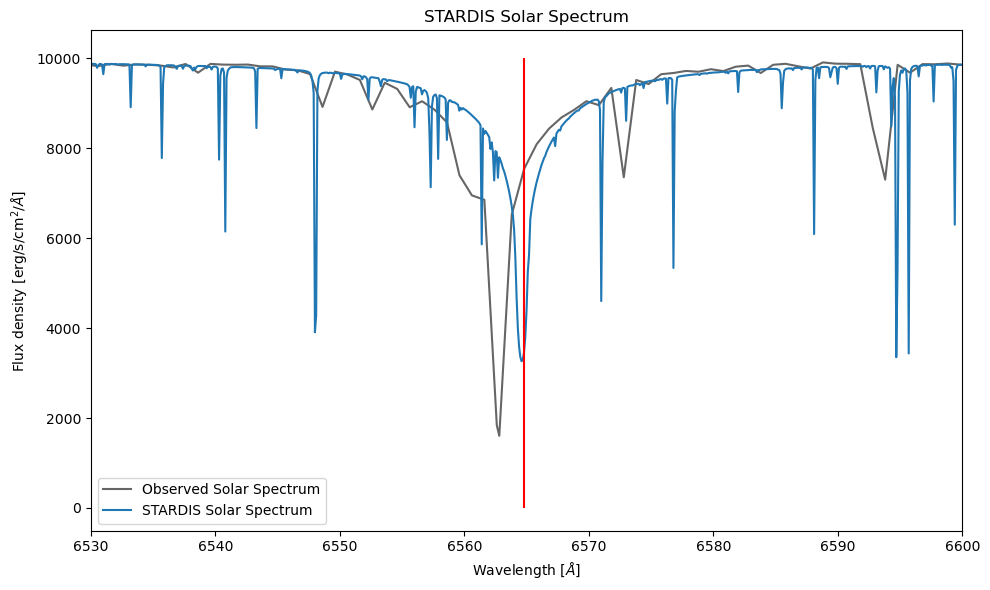

In [21]:

plt.figure(figsize=(10,6))

plt.plot(wave, flux, label='Observed Solar Spectrum', color = 'black', alpha = 0.6)
plt.plot(sim.lambdas, y_new, label='STARDIS Solar Spectrum')
plt.legend()
plt.xlim((6530,6600))
plt.title("STARDIS Solar Spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
plt.tight_layout()
plt.vlines(6564.8, ymin=0, ymax=10000, color='red', label='H-alpha line')
plt.show()
# Linear fit of spectrum 
# Use function to create an array of data point and then divide
# numpy Scipy


## Boltzmann Curve

[2.57957752e+13 2.57954018e+13 2.57950283e+13 ... 2.16328516e+13
 2.16324190e+13 2.16319864e+13] J / (s m3)
[9800. 9800. 9800. ... 9800. 9800. 9800.]


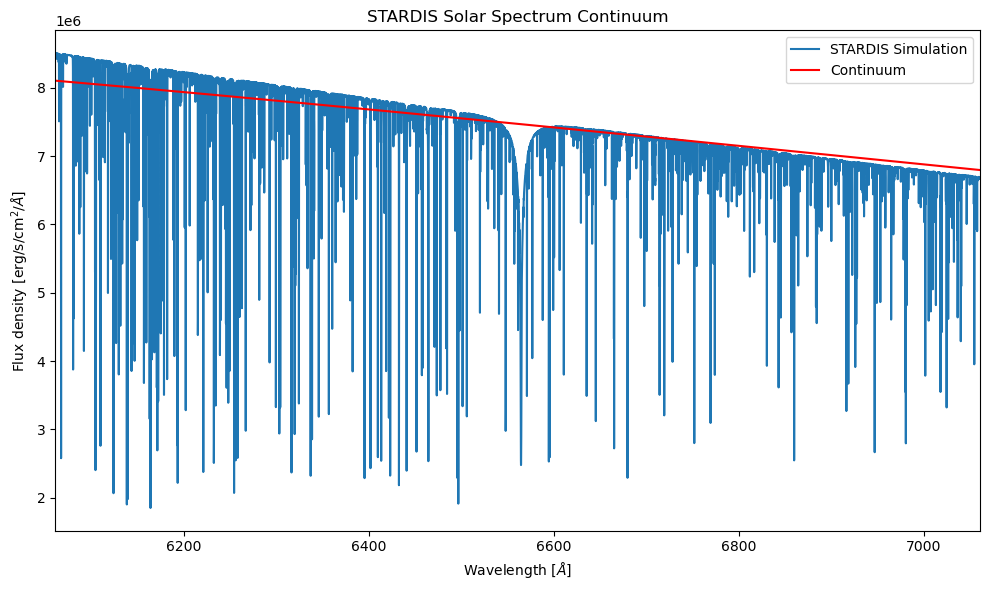

In [23]:
h = 6.62607015e-34 *u.J*u.s  # Planck's constant in J*s
c = 299792458 *u.m/u.s  # Speed of light in m/s
k = 1.380649e-23 *u.J/u.K  # Boltzmann's constant in J/K
T = 5860 *u.K  # Temperature of the Sun in K

b_x = np.linspace(6061,7061,10000) * u.Angstrom 
b_x = b_x.to(u.m)  # Convert wavelength from Angstrom to meters

b_y = 2*h*c**2/b_x**5 * 1/(np.exp(h*c/(b_x*k*T))-1)
flux_lambda = np.pi * u.sr * b_y.to(u.erg/u.s/u.cm**2/u.Angstrom) #Convert to flux density

print(b_y)
b_y_new = b_y / flux_lambda *9800*np.pi * u.sr
print(b_y_new.decompose())
continuum_visualizer(b_x.to(u.Angstrom), flux_lambda, sim.lambdas, sim.spectrum_lambda)

[9.8e+10 9.8e+10 9.8e+10 ... 9.8e+10 9.8e+10 9.8e+10] cm2 Angstrom J / (erg m3)


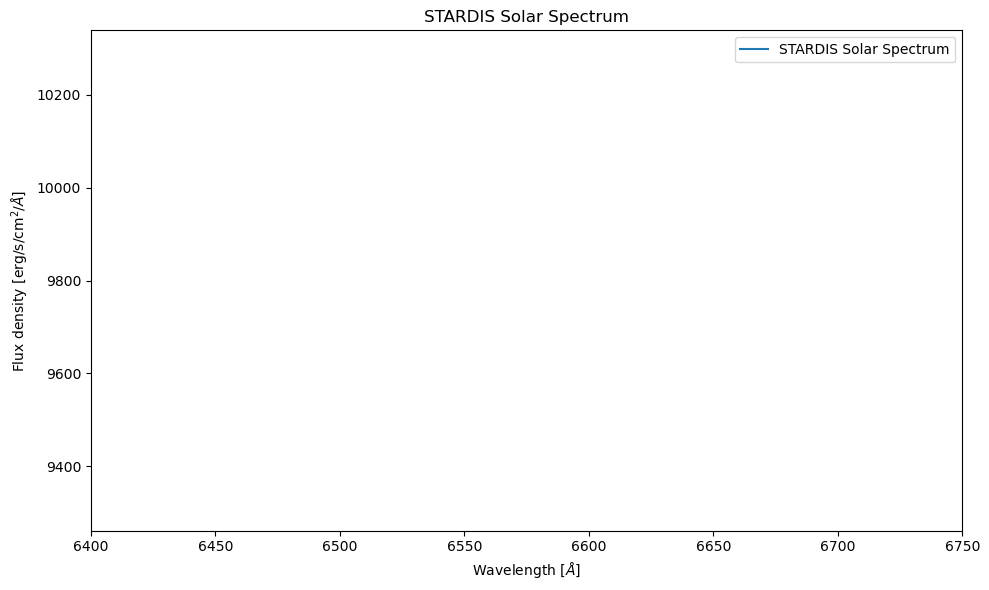

In [24]:
plt.figure(figsize=(10,6))

print(b_y_new)
#plt.plot(wave, flux, label='Observed Solar Spectrum', color = 'black', alpha = 0.6)
plt.plot(b_x, b_y_new.decompose(), label='STARDIS Solar Spectrum')
plt.legend()
plt.xlim((6400,6750))
plt.title("STARDIS Solar Spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
plt.tight_layout()

plt.show()


## Sigma Clipping

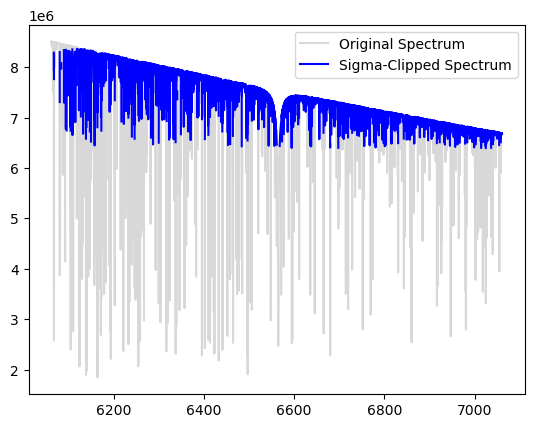

[8507984.68640551 8507755.51529767 8507524.36560838 ... 6691992.18823209
 6687610.99647886 6679946.38028694]
[-- -- -- ... 6691992.188232095 6687610.996478862 6679946.380286936]


numpy.ma.core.MaskedArray

In [25]:
filtered_data = sigma_clip(sim.spectrum_lambda.value, sigma=2, maxiters=None)
plt.plot(sim.lambdas, sim.spectrum_lambda, label='Original Spectrum', alpha=0.3, color='gray')
plt.plot(sim.lambdas, filtered_data, label='Sigma-Clipped Spectrum', color='blue')
plt.legend()
plt.show()
print(sim.spectrum_lambda/ u.erg * u.s * u.cm**2 * u.Angstrom)
print(filtered_data)
type(sim.spectrum_lambda)
type(filtered_data)

[6065.000000000014, 6066.300000000019, 6066.900000000021, 6067.000000000022, 6067.300000000023, 6067.400000000023, 6069.30000000003, 6073.000000000044, 6080.000000000069, 6080.1000000000695, 6080.30000000007, 6080.600000000071, 6080.800000000072, 6081.700000000074, 6083.10000000008, 6083.4000000000815, 6083.500000000082, 6084.100000000084, 6085.500000000088, 6087.900000000098, 6088.300000000099, 6088.6000000001, 6089.300000000102, 6089.400000000103, 6089.500000000104, 6089.600000000104, 6091.30000000011, 6092.700000000114, 6092.800000000116, 6092.900000000116, 6093.400000000118, 6093.500000000118, 6093.600000000119, 6093.700000000119, 6093.800000000119, 6094.500000000122, 6094.800000000123, 6095.300000000125, 6095.400000000125, 6096.000000000127, 6096.100000000129, 6098.300000000136, 6098.400000000135, 6098.900000000138, 6099.000000000138, 6099.900000000142, 6100.000000000142, 6100.300000000142, 6100.400000000143, 6101.600000000148, 6101.900000000149, 6102.000000000149, 6103.6000000001

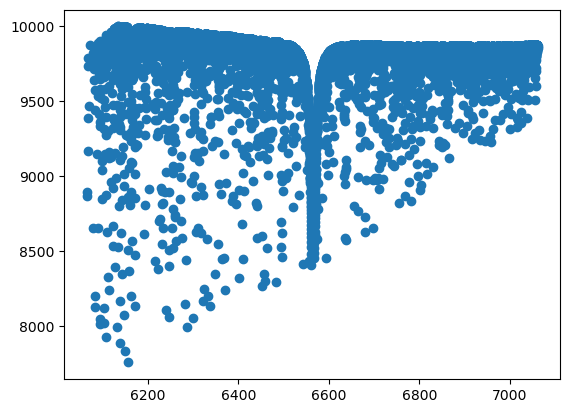

In [29]:
pre_sigma_x= sim.lambdas / u.Angstrom
pre_sigma_y = filtered_data

sigma_x = []
for i in range(len(pre_sigma_x)):
    if pre_sigma_y[i] != np.nan:
        sigma_x.append(float(pre_sigma_x[i]))

sigma_y = []
for i in pre_sigma_y:
    if i != np.nan:
        sigma_y.append(float(i))
print(sigma_x)
print(sigma_y)
print(type(sigma_x))
print(type(filtered_data))

slope, intercept = np.polyfit(sigma_x, sigma_y, 1)
result = np.array(sigma_x) * slope + intercept

sigma_y_new = sigma_y / result *9800

plt.plot(sigma_x, sigma_y_new, 'o', label='Data')
print(slope)
print(intercept)

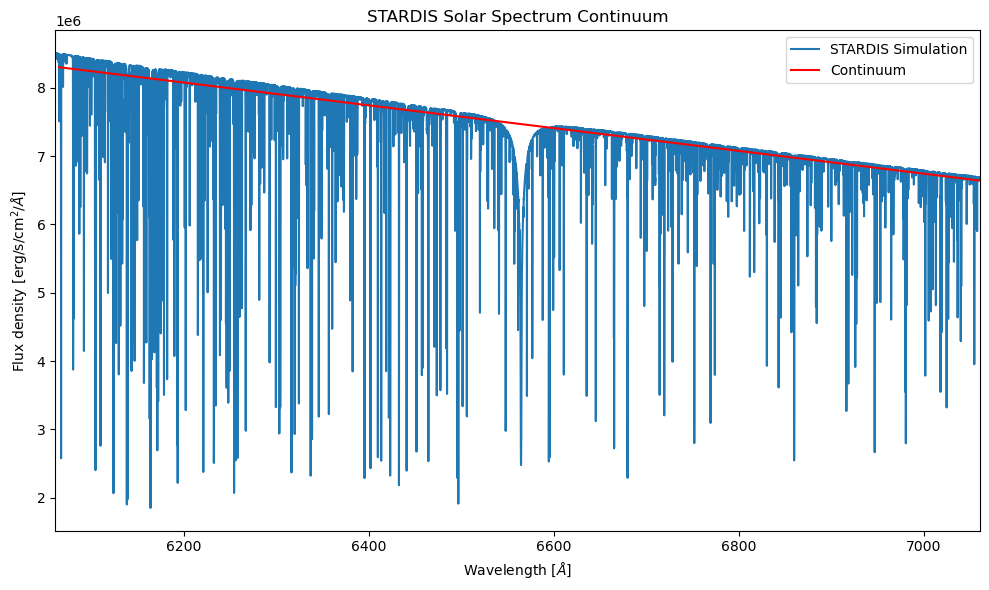

In [30]:

continuum_visualizer(sigma_x, result, sim.lambdas, sim.spectrum_lambda)

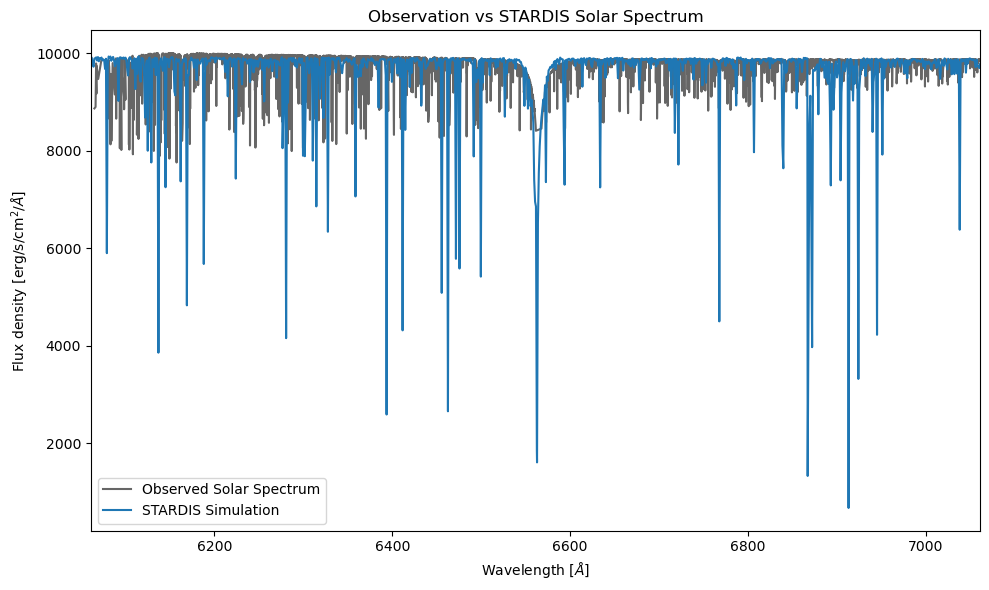

In [32]:
bass_compare(sigma_x, sigma_y_new, wave, flux)

## Specutils Continuum Fitting

In [34]:
from specutils.fitting import fit_generic_continuum
from specutils import Spectrum1D

In [35]:
# Convert the spectrum into one variable
spec = Spectrum1D(flux=sim.spectrum_lambda, spectral_axis=sim.lambdas,)
# Fit the continuum to the variable
s_fit = fit_generic_continuum(spec)
# retrieve the fitted continuum values
y_fit = s_fit(spec.spectral_axis)
# plot the original spectrum and the fitted continuum
continuum_visualizer(spec.spectral_axis, y_fit)

TypeError: continuum_visualizer() missing 2 required positional arguments: 'x2' and 'y2'

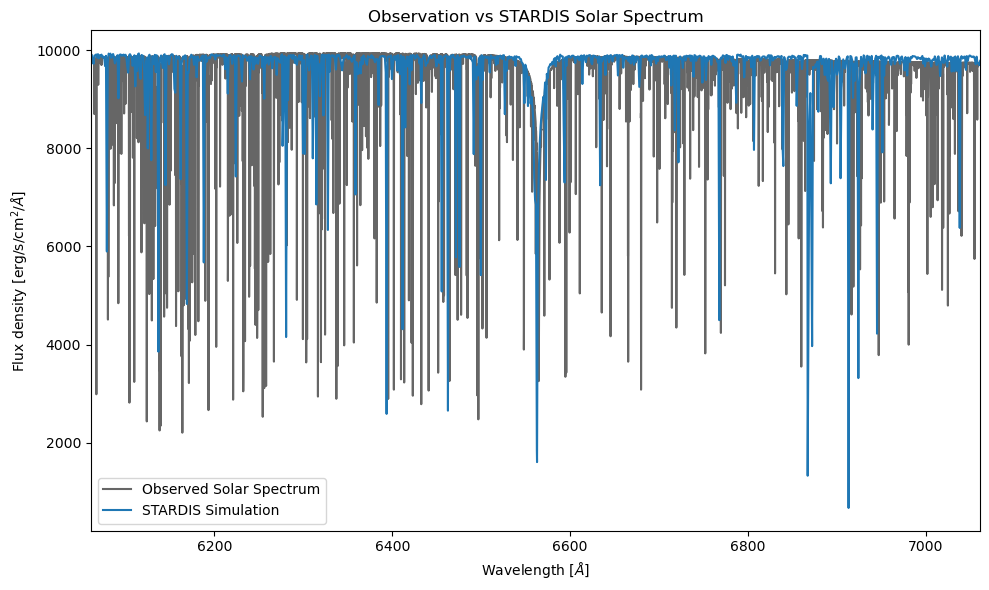

In [36]:
# Normalize the spectrum by dividing the original spectrum by the fitted continuum and multiply by a scaling factor
spec_norm = spec / y_fit*9700
bass_compare(spec.spectral_axis, spec_norm.flux, wave, flux)

## Interactive Plot


In [ ]:
def update_plot(xlim_range):
    plt.figure(figsize=(10,6))
    plt.plot(wave_vac, flux, label='Observed Solar Spectrum', color = 'black', alpha = 0.6)
    plt.plot (sim.lambdas, y_best, label='STARDIS Simulation')
    #plt.xlim((6530,6600)) # Zoom in on the H-alpha line
    plt.xlim((xlim_range[0], xlim_range[1])) # Zoom in on the O2 B line
    plt.ylim((9000, 10000))
    plt.title("STARDIS Solar Spectrum")
    plt.xlabel(r"Wavelength [$\AA$]")
    plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
    plt.tight_layout()

    
    #plt.vlines(6564.6, ymin=0, ymax=10000, color='red', label='H-alpha line')
    #plt.vlines(6869.4, ymin=0, ymax=10000, color='red', label='O2 B line')
    plt.legend()
    plt.show()

# Create range slider (min, max)
interact(update_plot, xlim_range=widgets.FloatRangeSlider(
    value=[6450, 6675], min=6000, max=7000, step=1,
    description='X-Axis Limits:', layout=widgets.Layout(width='80%')))


interactive(children=(FloatRangeSlider(value=(6450.0, 6675.0), description='X-Axis Limits:', layout=Layout(wid…

<function __main__.update_plot(xlim_range)>